In [1]:
import xarray as xr

[pyodide]: Loading numpy, pandas, python-dateutil, pytz, six, tzdata, xarray
[pyodide]: Loaded numpy, pandas, python-dateutil, pytz, six, tzdata, xarray
[pyodide]: Loading pyarrow, pyodide-unix-timezones
[pyodide]: Loaded pyarrow, pyodide-unix-timezones
[pyodide]: Loading cloudpickle
[pyodide]: Loaded cloudpickle
[pyodide]: Loading Bottleneck
[pyodide]: Loaded Bottleneck
[pyodide]: Loading cftime
[pyodide]: Loaded cftime
[pyodide]: Loading PyYAML, click, dask, fsspec, locket, partd, toolz
[pyodide]: Loaded PyYAML, click, dask, fsspec, locket, partd, toolz
[pyodide]: Loading scipy
[pyodide]: Loaded scipy
[pyodide]: Loading threadpoolctl
[pyodide]: Loaded threadpoolctl
[pyodide]: Memory usage has grown to 124.2MiB (from 49.9MiB) for this notebook
[pyodide]: Loaded 70 new dynamic libraries (76 total for this notebook)


In [2]:
import netCDF4

[pyodide]: Loading netCDF4
[pyodide]: Loaded netCDF4
[pyodide]: Loaded 3 new dynamic libraries (79 total for this notebook)


In [3]:
from pathlib import Path

data = Path("data")
data.mkdir(exist_ok=True)

In [4]:
import shutil
from urllib.request import urlopen

In [5]:
from contextlib import contextmanager

In [6]:
@contextmanager
def open_data_array(domain: str, name: str) -> xr.DataArray:
    url = f"http://object-store.os-api.cci1.ecmwf.int/esiwacebucket/{domain}/{name}"
    path = data / Path(url).name

    if not path.exists():
        with urlopen(url) as response:
            with path.open("wb") as file:
                shutil.copyfileobj(response, file)

    # all examples are regridded to regular latitude-longitude grids in NetCDF4 format
    ds = xr.open_dataset(path, engine="netcdf4")

    # all examples only contain a single variable
    (var,) = list(ds)

    try:
        yield ds[var]
    finally:
        path.unlink(missing_ok=True)

In [7]:
DATASET_PATHS = [
    ("hplp", "hplp_ml_regridded_q_025deg_levels_10_137_steps_228_240.nc"),
    ("hplp", "hplp_sfc_regridded_t_025deg_steps_228_240.nc"),
    ("hplp", "hplp_sfc_regridded_tp_025deg_steps_228_240.nc"),
    ("OpenIFS", "OpenIFS_pl_regridded_q_025deg_steps_114_120_levels_100_1000.nc"),
    ("OpenIFS", "OpenIFS_sfc_regridded_t_025deg_steps_114_120.nc"),
    ("OpenIFS", "OpenIFS_sfc_regridded_tp_025deg_steps_114_120.nc"),
    ("NextGEMS_EW3_ICON_ngc4008", "NextGEMS_regridded_hus_025deg_steps_44_45.nc"),
    ("NextGEMS_EW3_ICON_ngc4008", "NextGEMS_regridded_pr_025deg_steps_44_45.nc"),
    ("ICON-XPP", "ICONXPP_regridded_t_025deg_steps_2026-05_06.nc"),
    ("ICON-XPP", "ICONXPP_regridded_tp_025deg_steps_2026-05_06.nc"),
]

In [8]:
import copy

import earthkit.plots
import earthkit.plots.utils.time_utils
import numpy as np
import matplotlib.pyplot as plt


def quickplot(
    da: xr.DataArray,
    vrange: None | tuple[float, float] = None,
    error: bool = False,
    title: str = "{default_title}",
    time: None | str = None,
    **kwargs,
) -> None:
    if "x" not in kwargs:
        for x in ["lon", "longitude"]:
            if x in da.dims:
                kwargs["x"] = x
                break
    if "y" not in kwargs:
        for y in ["lat", "latitude"]:
            if y in da.dims:
                kwargs["y"] = y
                break
    if "x" in kwargs and "y" in kwargs:
        da = da.isel(
            {d: slice(None) if d in (kwargs["x"], kwargs["y"]) else 0 for d in da.dims}
        )

    da_min = np.nanmin(da)
    da_max = np.nanmax(da)

    if vrange is None:
        vmin = da_min
        vmax = da_max

        if error:
            vmax = max(abs(vmin), abs(vmax))
            vmin = -vmax
    else:
        vmin, vmax = vrange

    # compute the default style that earthkit.plots would apply
    source = earthkit.plots.sources.get_source(da)
    style = copy.deepcopy(
        earthkit.plots.styles.auto.guess_style(
            source,
            units=getattr(da, "units", "1"),
        )
    )
    style._levels = earthkit.plots.styles.levels.Levels(np.linspace(vmin, vmax, 22))
    style._legend_kwargs["ticks"] = np.linspace(vmin, vmax, 5)

    if error:
        style._colors = "coolwarm"

    extend_left = da_min < vmin
    extend_right = da_max > vmax

    extend = {
        (False, False): "neither",
        (True, False): "min",
        (False, True): "max",
        (True, True): "both",
    }[(extend_left, extend_right)]
    style._legend_kwargs["extend"] = extend

    # extract datetime and provide it for plotting labels
    time = None if time is None else source.metadata(time)
    time = source.metadata("time_counter") if time is None else time
    time = source.metadata("valid_time") if time is None else time
    time = source.metadata("time") if time is None else time

    class DataArray(da.__class__):
        __slots__ = ()

        def datetime(self):
            datetime = (
                None
                if time is None
                else earthkit.plots.utils.time_utils.to_pydatetime(time)
            )
            return {"base_time": datetime, "valid_time": datetime}

    data = da.copy(deep=False)
    data.__class__ = DataArray

    chart = earthkit.plots.Map()
    chart.pcolormesh(data, style=style, **kwargs)
    chart.coastlines()
    chart.gridlines()
    chart.legend()
    chart.title(title.format(default_title=chart._default_title_template))

    chart.show()

    plt.clf()
    plt.close("all")

[pyodide]: Loading Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, click-plugins, cligj, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-plots-default-styles, earthkit-utils, eccodes, entrypoints, filelock, findlibs, fiona, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, referencing, rpds-py, shapely, tqdm, typing_extensions
[pyodide]: Loaded Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, click-plugins, cligj, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-plots-default-styles, earthkit-utils, eccodes, entrypoints, filelock, findlibs, fiona, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, pdbufr, pillow, platformd

/lib/python3.13/site-packages/earthkit/data/core/config.py:292: UserWarning: only soft file lock is available
  from filelock import FileLock


[pyodide]: Loading uncertainties
[pyodide]: Loaded uncertainties
[pyodide]: Memory usage has grown to 214.8MiB (from 124.2MiB) for this notebook
[pyodide]: Loaded 99 new dynamic libraries (178 total for this notebook)


/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


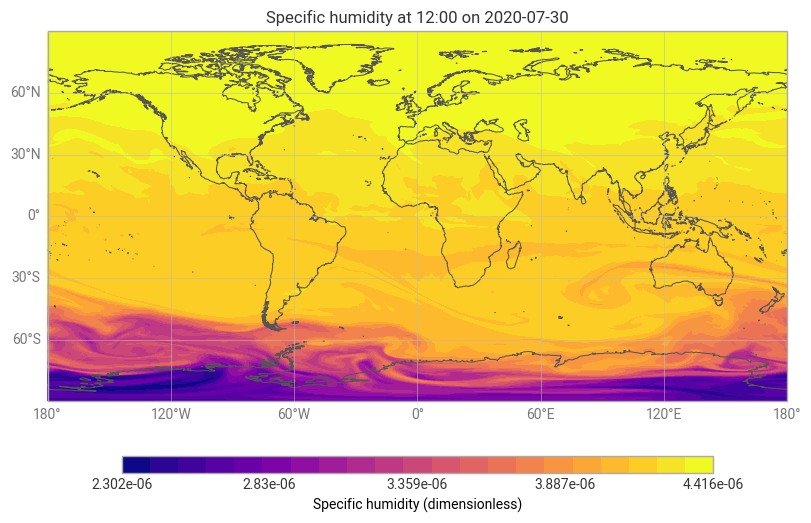

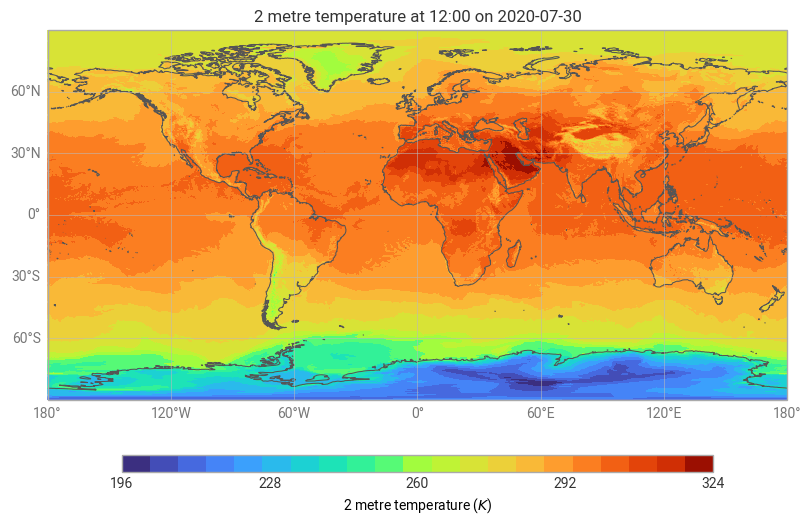

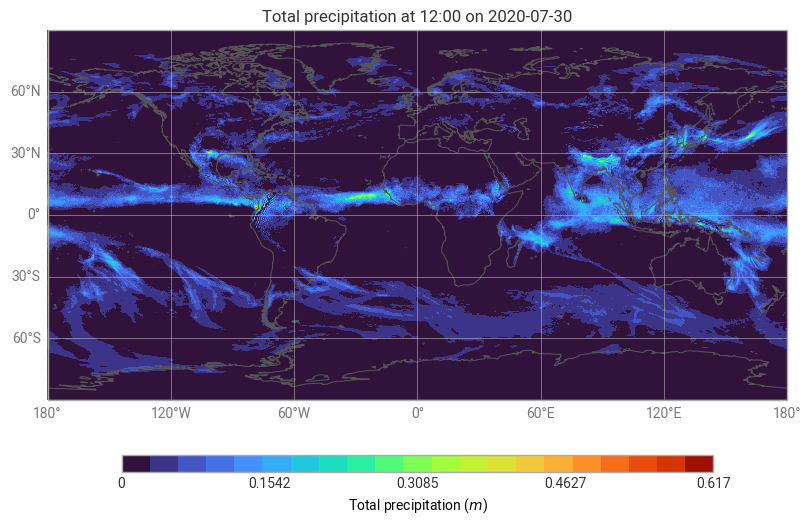

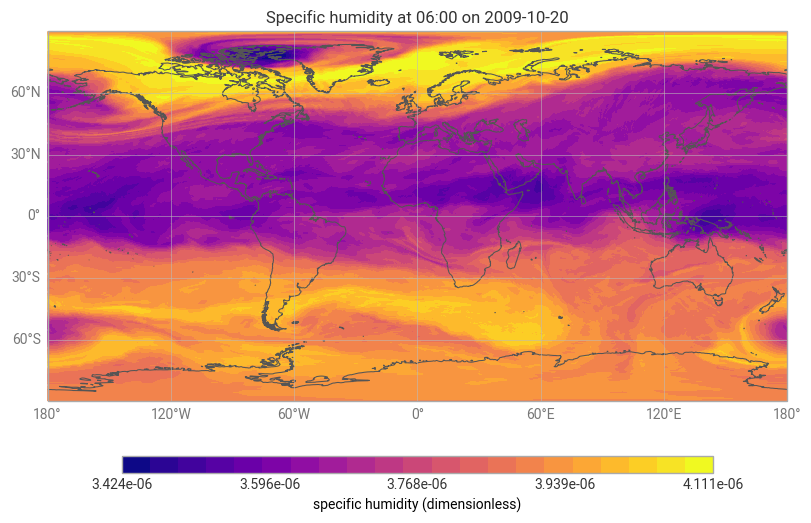

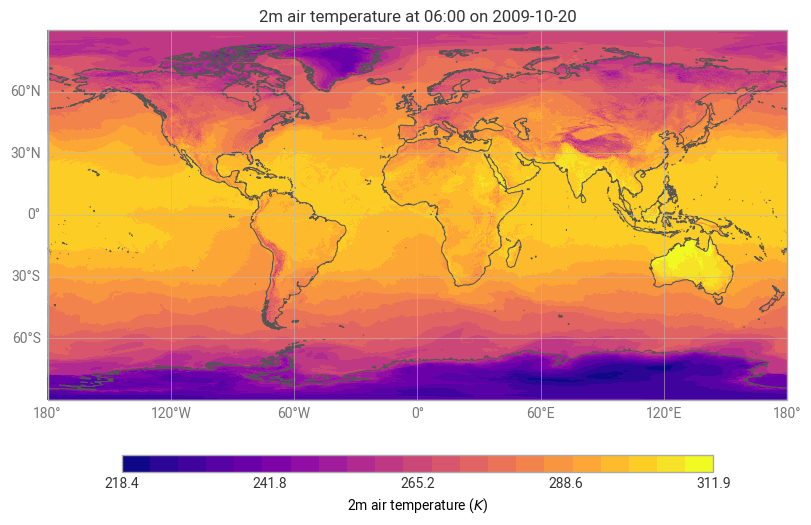

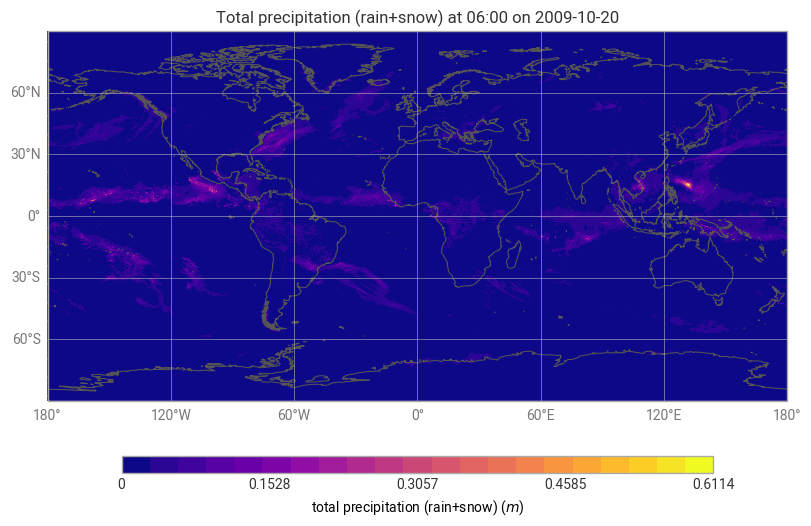

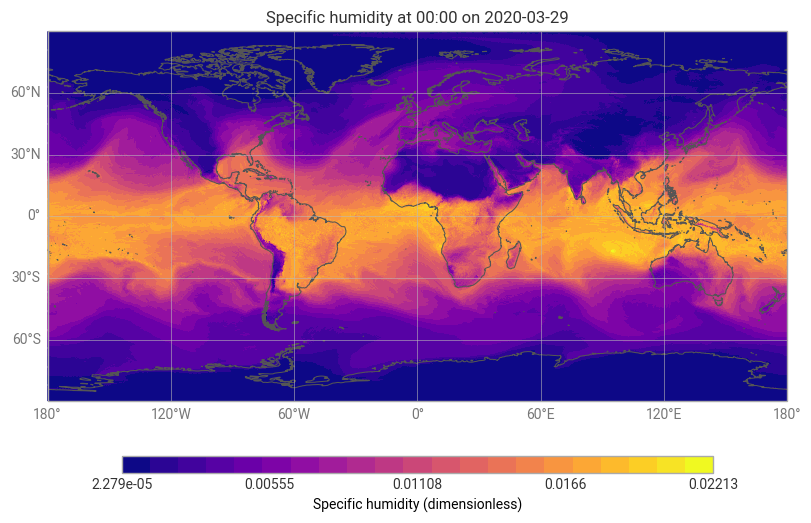

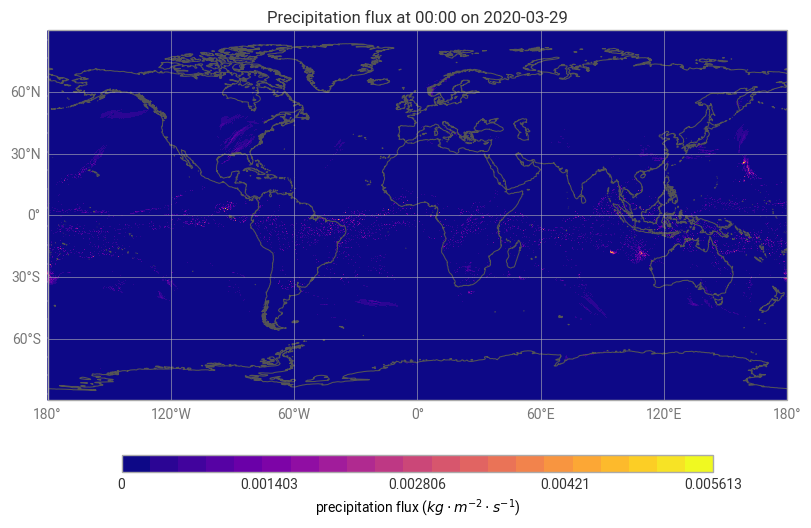

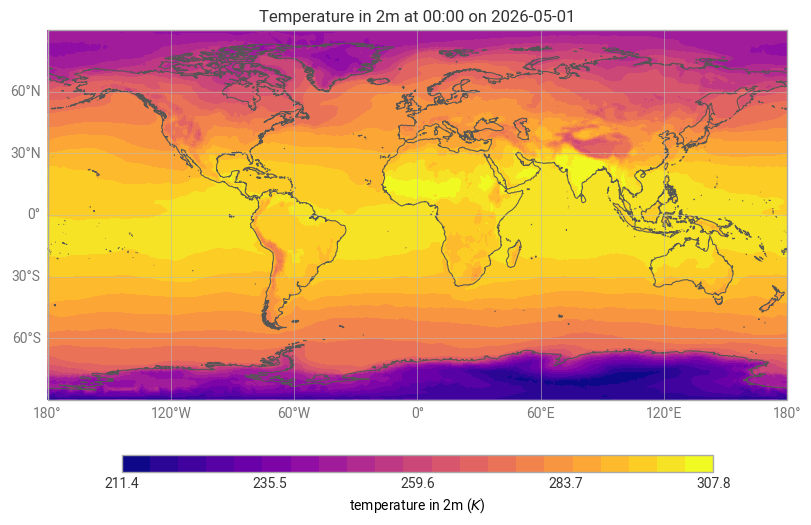

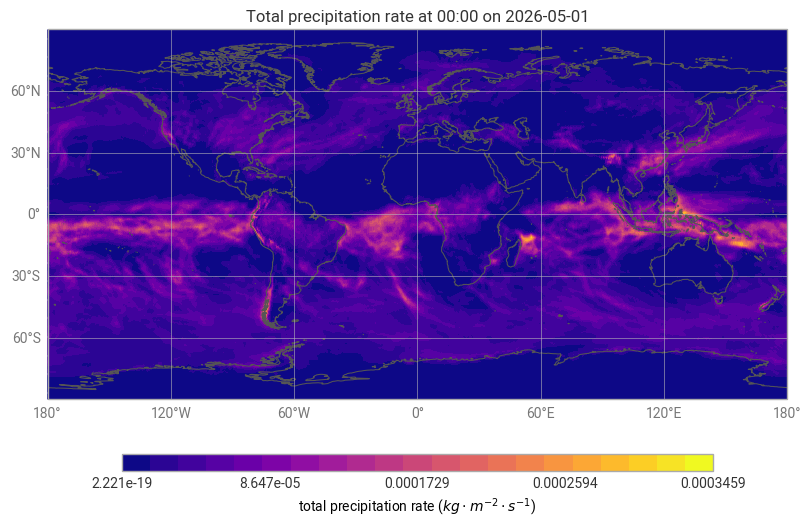

[pyodide]: Memory usage has grown to 1.2GiB (from 214.8MiB) for this notebook


[pyodide]: Loaded 2 new dynamic libraries (180 total for this notebook)


In [9]:
for path in DATASET_PATHS:
    with open_data_array(*path) as da:
        quickplot(da)

In [10]:
from numcodecs_wasm_sz3 import Sz3

# from numcodecs_wasm_pressio import Pressio
from numcodecs_wasm_zfp import Zfp
from numcodecs_wasm_sperr import Sperr
from numcodecs_wasm_ebcc import Ebcc
from numcodecs_wasm_bit_round import BitRound
from numcodecs_wasm_lc import Lc
from numcodecs_safeguards import SafeguardedCodec
import xarray_safeguards

[pyodide]: Loading Deprecated, compression-safeguards, leb128, numcodecs, numcodecs-bitmap-index, numcodecs-combinators, numcodecs-delta, numcodecs-observers, numcodecs-safeguards, numcodecs-shuffle, numcodecs-tokenize, numcodecs-zero, numcodecs_wasm, numcodecs_wasm_bit_round, numcodecs_wasm_ebcc, numcodecs_wasm_lc, numcodecs_wasm_sperr, numcodecs_wasm_sz3, numcodecs_wasm_zfp, numpy_quaddtype, semver, sly, wrapt, xarray-safeguards
[pyodide]: Loaded Deprecated, compression-safeguards, leb128, numcodecs, numcodecs-bitmap-index, numcodecs-combinators, numcodecs-delta, numcodecs-observers, numcodecs-safeguards, numcodecs-shuffle, numcodecs-tokenize, numcodecs-zero, numcodecs_wasm, numcodecs_wasm_bit_round, numcodecs_wasm_ebcc, numcodecs_wasm_lc, numcodecs_wasm_sperr, numcodecs_wasm_sz3, numcodecs_wasm_zfp, numpy_quaddtype, semver, sly, wrapt, xarray-safeguards
[pyodide]: Loading crc32c
[pyodide]: Loaded crc32c
[pyodide]: Loading msgpack
[pyodide]: Loaded msgpack
[pyodide]: Loaded 14 new dy

In [11]:
da

<xarray.DataArray 'tot_prec_rate' (time: 2, latitude: 721, longitude: 1440)> Size: 17MB
[2076480 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 16B 2026-05-01 2026-06-01
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    CDI_grid_type:                unstructured
    long_name:                    total precipitation rate
    number_of_grid_in_reference:  1
    param:                        52.1.0
    standard_name:                tot_prec_rate
    units:                        kg m-2 s-1

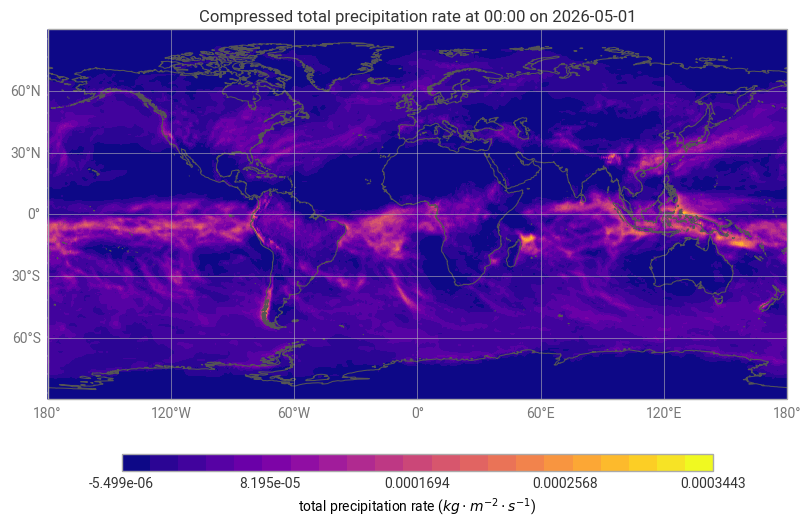

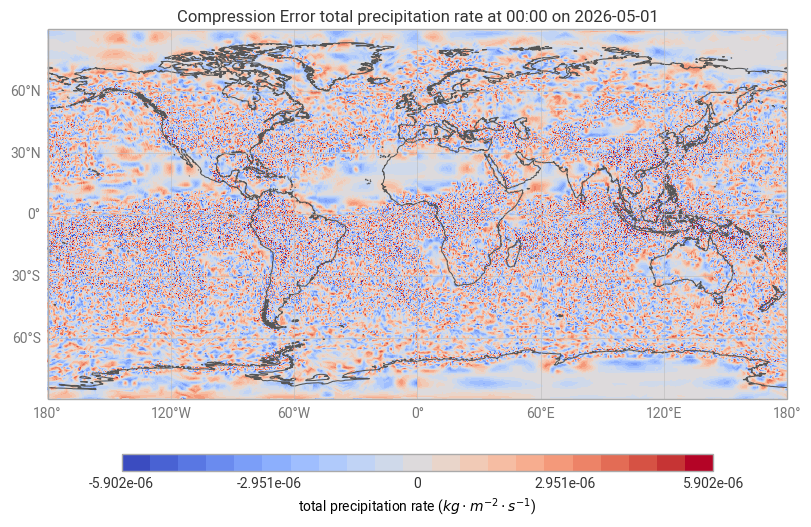

In [12]:
codec = Sz3(eb_mode="rel", eb_rel=0.01)

da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

quickplot(da_dec, title="Compressed {default_title}")

da_err = da_dec - da

quickplot(da_err, title="Compression Error {default_title}", error=True)

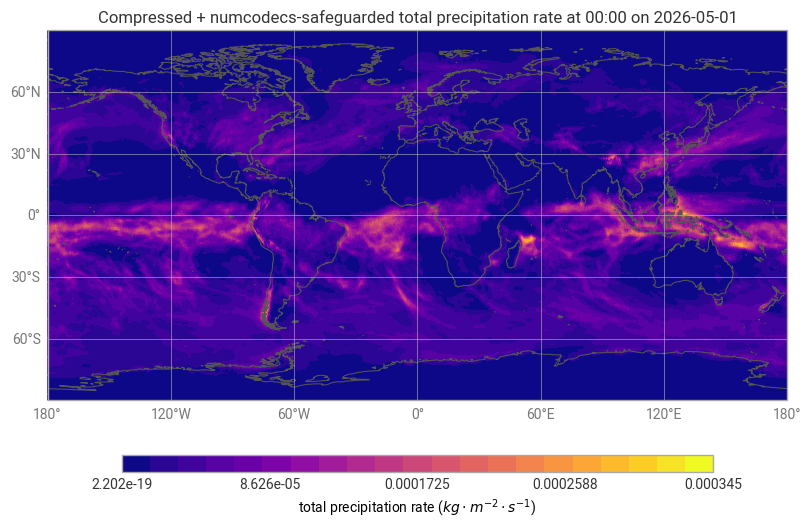

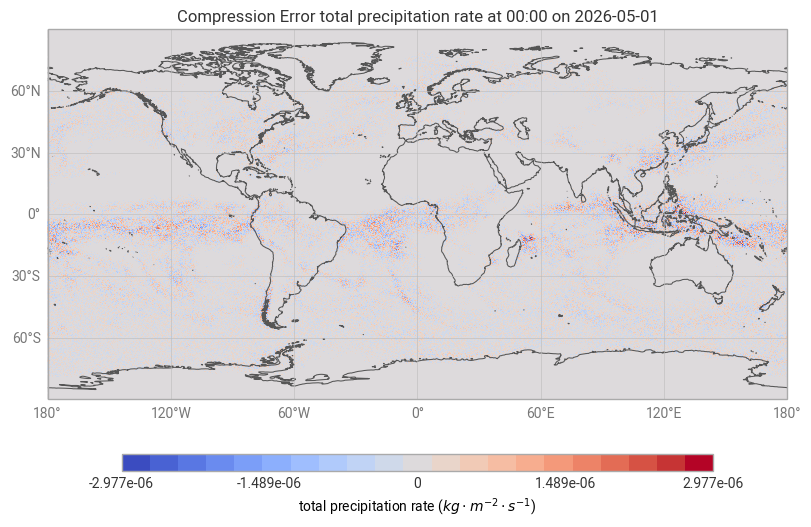

In [13]:
sg = SafeguardedCodec(
    codec=codec,
    safeguards=[
        dict(kind="eb", type="rel", eb=0.01),
    ],
)

da_sg_enc = sg.encode(da.values)
da_sg_dec = da.copy(data=sg.decode(da_sg_enc))

quickplot(da_sg_dec, title="Compressed + numcodecs-safeguarded {default_title}")

da_sg_err = da_sg_dec - da

quickplot(da_sg_err, title="Compression Error {default_title}", error=True)

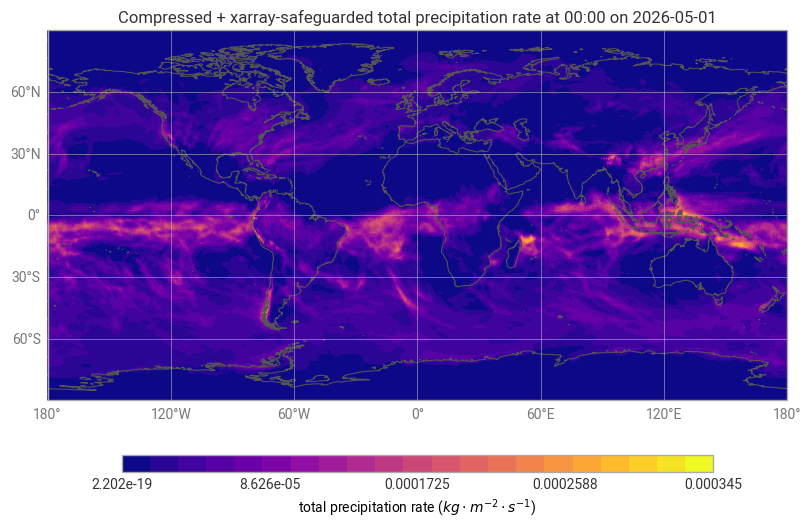

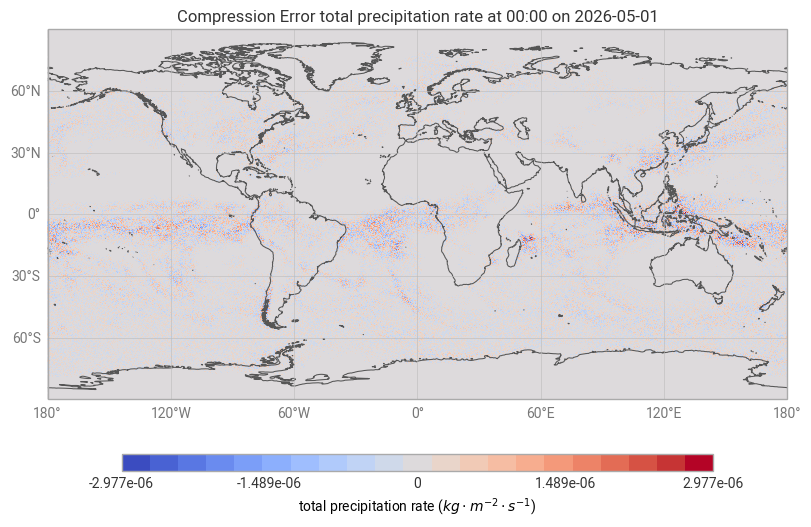

[pyodide]: Memory usage has grown to 1.4GiB (from 1.2GiB) for this notebook


In [14]:
da_corr = xarray_safeguards.produce_data_array_correction(
    data=da,
    prediction=da_dec,
    safeguards=[
        dict(kind="eb", type="rel", eb=0.01),
    ],
)
da_sg_dec = xarray_safeguards.apply_data_array_correction(
    prediction=da_dec, correction=da_corr
)

quickplot(da_sg_dec, title="Compressed + xarray-safeguarded {default_title}")

da_sg_err = da_sg_dec - da

quickplot(da_sg_err, title="Compression Error {default_title}", error=True)